# MLOps in Practice:

**Audience:** Faculty & undergraduate students  |  **Runtime:** ~8–10 min on a free Colab GPU

> ⚙️ **Before you start:** Go to `Runtime → Change runtime type → T4 GPU`, then `Runtime → Run all` (or run cells one by one as we discuss them).

---

## 🎯 What this notebook teaches

Most ML courses end at *"the model reached 99% accuracy."* Industry starts there. **MLOps** is everything needed to make a model *reproducible, trackable, testable, deployable, and monitorable*.

| # | Section | MLOps concept | Tool used here | Industry equivalent |
|---|---------|---------------|----------------|---------------------|
| 1 | The naive notebook | Why MLOps exists | — | — |
| 2 | Reproducibility | Seeds & configs | Python config dict | Hydra / YAML configs |
| 3 | Experiment tracking | Compare runs scientifically | **MLflow Tracking** | MLflow / W&B / Neptune |
| 4 | Model registry | Versioned, governed models | **MLflow Registry** | MLflow / SageMaker Registry |
| 5 | Validation gates | "CI/CD for models" | pytest-style checks | GitHub Actions + tests |
| 6 | Serving | Model behind an interface | **Gradio** demo app | FastAPI + Docker + K8s |
| 7 | Monitoring & drift | Models decay in production | Simulated drift + MLflow | Evidently AI / Arize |
| 8 | The full lifecycle | Putting it together | Recap diagram | — |

**Stack:** 100% open-source — PyTorch, MLflow, Gradio, torchvision.

> 💡 *Why not LangChain?* LangChain is a framework for chaining **LLM** calls (prompts, agents, RAG). For a CNN training pipeline it adds complexity without benefit, so we deliberately leave it out — choosing the *right* tool is itself an MLOps lesson.


## ⚙️ Setup (≈1 min)
PyTorch and torchvision are pre-installed on Colab; we only add MLflow (tracking + registry) and Gradio (serving demo).

In [1]:
!rm -f requirements.txt
!wget https://raw.githubusercontent.com/kumarsirish/FDP-MLOPS/main/requirements.txt
# Install the MLOps tooling from requirements.txt
%pip install -r requirements.txt

import os
import torch, torchvision, mlflow
from dotenv import load_dotenv

print("torch:", torch.__version__, "| torchvision:", torchvision.__version__, "| mlflow:", mlflow.__version__)
print("GPU available:", torch.cuda.is_available())

#load_dotenv()
#HF_TOKEN = userdata.get('HF_TOKEN')
#HF_TOKEN = os.getenv('HF_TOKEN')  # optional — only needed if pushing to Hugging Face Hub

--2026-06-14 11:52:20--  https://raw.githubusercontent.com/kumarsirish/FDP-MLOPS/main/requirements.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 70 [text/plain]
Saving to: ‘requirements.txt’

requirements.txt    100%[===================>]      70  --.-KB/s    in 0s      

2026-06-14 11:52:20 (1.53 MB/s) - ‘requirements.txt’ saved [70/70]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 96.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 114.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━

In [2]:
# Load MNIST and create dataloaders (shared by every section below)
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on: {DEVICE}")

# 0.1307 = mean pixel value of the entire MNIST training set (60,000 images)
# 0.3081 = standard deviation of the entire MNIST training set
# These are fixed, pre-computed constants specific to MNIST — not arbitrary numbers.
# Normalize subtracts the mean and divides by std so pixel values are centred around 0
# with unit variance. This makes training faster and more stable.
# If you used a different dataset (e.g. CIFAR-10), you would use that dataset's own mean/std.
MNIST_MEAN = (0.1307,)
MNIST_STD  = (0.3081,)

# Training transform includes augmentation to make the model robust to drawing variations:
# RandomAffine applies small rotations (±10°) and translations (up to 10% shift)
# so the model learns to handle slightly tilted or off-center digits — like real user input
train_transform = transforms.Compose([
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(MNIST_MEAN, MNIST_STD),
])

# Test transform has NO augmentation — we evaluate on clean images to measure true accuracy
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MNIST_MEAN, MNIST_STD),
])

train_ds_full = datasets.MNIST("./data", train=True,  download=True, transform=train_transform)
test_ds       = datasets.MNIST("./data", train=False, download=True, transform=test_transform)

# Use 10,000 samples on CPU for a fast demo (~1 min per run); full 60k on GPU
if DEVICE == "cpu":
    train_ds = Subset(train_ds_full, range(10_000))
    print("CPU mode: using 10,000 training samples for speed")
else:
    train_ds = train_ds_full

# num_workers=0 is safest on local/Windows machines
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=512, shuffle=False, num_workers=0)

print(f"{len(train_ds):,} train | {len(test_ds):,} test | device: {DEVICE}")

Running on: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 492kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.90MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.7MB/s]


60,000 train | 10,000 test | device: cuda


---
# Part 1 — The "naive" student notebook 🚫

This is how models are *usually* trained in coursework: hardcoded hyperparameters, no logging, nothing saved. **Run it — it works!** Then we'll see why it fails in the real world.

In [3]:
# A deliberately tiny CNN so the whole demo fits in ~10 minutes
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(

            # It takes the greyscale input -1
            # looks for 16 patterns using 3x3 pixel filter
            # This reduces the image size by half (from 28x28 to 14x14).
            # It keeps only the most important information from each 3x3 pixel area.
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 28→14
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 14→7
            #2D to 1D conversion
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 64), nn.ReLU(),
            #This is the final output layer.
            #Since MNIST has 10 digits (0 through 9), we need exactly 10 output scores.
            nn.Linear(64, 10),
        )
    def forward(self, x):
        return self.net(x)

# --- shared helpers (we reuse these in every later section) ---
def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    for x, y in loader: #x-> images, y-> labels
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad() # Resets the gradient
        loss = F.cross_entropy(model(x), y) # Calculates the loss
        loss.backward() # recalculates the weights
        optimizer.step() # updates the weights
        total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)

#Runs the model on all data without training, counts correct predictions, and returns the accuracy as a fraction.
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        correct += (model(x).argmax(dim=1) == y).sum().item()
    return correct / len(loader.dataset)

# --- the "naive" training run: everything hardcoded, nothing recorded ---
model = SmallCNN().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)   # magic number!
loss = train_one_epoch(model, train_loader, optimizer)
acc = evaluate(model, test_loader)
print(f"loss={loss:.4f}  test_accuracy={acc:.4f}  ✅ ...and now what?")

loss=0.6481  test_accuracy=0.9702  ✅ ...and now what?


### 🤔 Discussion: what just went wrong (even though it "worked")?

1. **Reproducibility** — run the cell again. Do you get the *same* accuracy? (No — random init & shuffling.)
2. **Memory** — you try `lr=0.005` tomorrow. Which run was better? Where is yesterday's number?
3. **The model is gone** — close this notebook and the trained weights vanish. Nothing was saved or versioned.
4. **No quality bar** — would you ship this to a hospital or a bank with zero automated checks?
5. **No serving / monitoring** — a model inside a notebook helps no one; and even deployed models *decay* as the world changes.

The rest of the notebook fixes these problems **one by one**.

---
# Part 2 — Reproducibility: seeds + configuration ✅

**Rule 1 of MLOps:** If you can't run it twice and get the same result, it didn't happen.
Two cheap habits fix most of it: **fix randomness** and **move magic numbers into a config object** (in real projects: a YAML file managed by tools like Hydra).

In [13]:
import random
import numpy as np

def set_seed(seed: int):
    """Fix every source of randomness we control."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# 2 epochs on both devices — GPU uses 60k samples, CPU uses 10k (set in cell 4)
EPOCHS = 2

CONFIG = {
    "model":      "SmallCNN",
    "lr":         0.001,
    "epochs":     EPOCHS,
    "batch_size": 256,
    "optimizer":  "Adam",
    "seed":       42,
}

> 🧪 **Mini-exercise:** wrap the naive training from Part 1 with `set_seed(42)` and run it twice — the numbers now match.
>
> 👩‍🏫 *For faculty:* full bit-wise determinism on GPU also needs `torch.use_deterministic_algorithms(True)` and pinned library versions (`requirements.txt` / Docker) — a great seminar topic on its own.

---
# Part 3 — Experiment tracking with MLflow 📊

Instead of memory, sticky notes, or `results_final_v2_REAL.txt`, every run now records its **parameters, metrics per epoch, and the trained model artifact** into MLflow. We run a small **learning-rate sweep** — exactly how teams pick hyperparameters in practice.

In [5]:
import time
import mlflow.pytorch
import os

os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"
mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("mnist-cnn-mlops")

SAMPLES = "60,000" if DEVICE == "cuda" else "10,000"
print(f"Device: {DEVICE} → running {CONFIG['epochs']} epochs on {SAMPLES} training samples")

def run_experiment(config: dict):
    """One fully-tracked training run."""
    set_seed(config["seed"])
    model = SmallCNN().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])

    with mlflow.start_run(run_name=f"lr={config['lr']}") as run:
        mlflow.log_params(config)
        for epoch in range(config["epochs"]):
            t0 = time.time()
            train_loss = train_one_epoch(model, train_loader, optimizer)
            val_acc = evaluate(model, test_loader)
            mlflow.log_metrics({
                "train_loss": train_loss,
                "val_accuracy": val_acc,
                "epoch_seconds": time.time() - t0,
            }, step=epoch)
            print(f"    epoch {epoch+1}/{config['epochs']}  loss={train_loss:.4f}  val_acc={val_acc:.4f}")
        try:
            mlflow.pytorch.log_model(model, name="model")
        except TypeError:
            mlflow.pytorch.log_model(model, "model")
        return run.info.run_id, val_acc

# Run LR sweep — epochs come from CONFIG, set in cell 8
for lr in [5e-4, 1e-3, 5e-3]:
    print(f"▶ Run with lr={lr}")
    run_experiment({**CONFIG, "lr": lr})

2026/06/14 11:53:31 INFO mlflow.tracking.fluent: Experiment with name 'mnist-cnn-mlops' does not exist. Creating a new experiment.


Device: cuda → running 2 epochs on 60,000 training samples
▶ Run with lr=0.0005
    epoch 1/2  loss=0.7934  val_acc=0.9574


2026/06/14 11:54:18 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/14 11:54:19 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


    epoch 2/2  loss=0.2320  val_acc=0.9732


2026/06/14 11:54:28 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


...

2026/06/14 11:55:21 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


▶ Run with lr=0.005
    epoch 1/2  loss=0.3170  val_acc=0.9784


2026/06/14 11:56:06 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/14 11:56:06 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


    epoch 2/2  loss=0.1028  val_acc=0.9845


2026/06/14 11:56:11 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


In [6]:
# Query the tracking store like a database — no more guessing which run was best
runs = mlflow.search_runs(experiment_names=["mnist-cnn-mlops"])
leaderboard = (
    runs[["run_id", "params.lr", "metrics.val_accuracy", "metrics.train_loss"]]
    .sort_values("metrics.val_accuracy", ascending=False) #<- highest accuracy first always at 0
    .reset_index(drop=True)
)
leaderboard

,run_id,params.lr,metrics.val_accuracy,metrics.train_loss
0,5abd895ea6cd49a6aa267cf1fdfc32de,0.005,0.9845,0.102804
1,16797ec57b334f2e96230683b6c71742,0.001,0.9798,0.169849
2,78bbbf2ab6a14c69b7bc88938e2713b4,0.0005,0.9732,0.231982


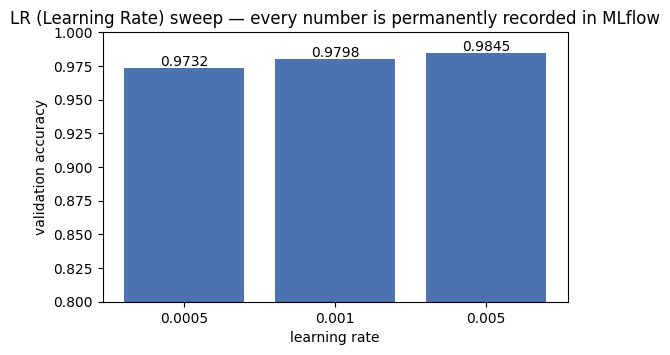

In [7]:
import matplotlib.pyplot as plt

# Drop rows with no lr (e.g. monitoring runs logged to the same experiment)
# then keep only the best result per unique lr, sorted low → high for the plot
lb = (
    leaderboard
    .dropna(subset=["params.lr", "metrics.val_accuracy"])
    .sort_values("metrics.val_accuracy", ascending=False)
    .drop_duplicates(subset="params.lr")
    .sort_values("params.lr", key=lambda s: s.astype(float))
    .reset_index(drop=True)
)

plt.figure(figsize=(6, 3.5))
plt.bar(lb["params.lr"], lb["metrics.val_accuracy"], color="#4C72B0")
plt.ylim(0.8, 1.0)
plt.xlabel("learning rate"); plt.ylabel("validation accuracy")
plt.title("LR (Learning Rate) sweep — every number is permanently recorded in MLflow")
for x, v in zip(lb["params.lr"], lb["metrics.val_accuracy"]):
    plt.text(x, v + 0.002, f"{v:.4f}", ha="center")
plt.show()

### 🖥️ Optional: open the full MLflow web UI inside Colab
The same dashboard ML teams stare at all day — run charts, diffs between runs, artifacts. (Opens in a new browser tab; pop-ups must be allowed.)
### mlflow ui --backend-store-uri ./mlruns


> 🧪 **Mini-exercise:** add `"epochs": 3` or a new lr (e.g. `1e-2`) to the sweep, rerun, and watch it appear in the leaderboard automatically.

---
# Part 4 — Model registry: versioned models with a lifecycle 🗃️

Tracking answers *"what did we try?"*. The **registry** answers *"which exact model is in production?"*. Every registered model gets a **version number** and can move through stages (staging → production → archived) — with a full audit trail of which run, code, and parameters produced it.

In [8]:
# Promote the BEST run model from the sweep into the registry
best = leaderboard.iloc[0] #<= best model is always at 0
print(f"Best run: lr={best['params.lr']}  val_acc={best['metrics.val_accuracy']:.4f}")

model_uri = f"runs:/{best['run_id']}/model"
registered = mlflow.register_model(model_uri, name="mnist-cnn")
print(f"✅ Registered 'mnist-cnn' as version {registered.version}")

Successfully registered model 'mnist-cnn'.
2026/06/14 11:56:12 WARNING mlflow.tracking._model_registry.fluent: Run with id 5abd895ea6cd49a6aa267cf1fdfc32de has no artifacts at artifact path 'model', registering model based on models:/m-63a269aedef24d33a0dc8a6e594a0f30 instead


Best run: lr=0.005  val_acc=0.9845
✅ Registered 'mnist-cnn' as version 1


Created version '1' of model 'mnist-cnn'.


In [9]:
# Anyone on the team (or a deployment server) can now pull the model BY NAME + VERSION —
# no emailing .pt files around.
prod_model = mlflow.pytorch.load_model(f"models:/mnist-cnn/{registered.version}").to(DEVICE)
print("Reloaded from registry — test accuracy:", f"{evaluate(prod_model, test_loader):.4f}")

Reloaded from registry — test accuracy: 0.9845


> 👩‍🏫 *For faculty:* the registry is also where **governance** lives — model cards, approvals, rollback to a previous version when a deployment goes wrong. The equivalent for *data* is **DVC** (git-style versioning of datasets)

---
# Part 5 — Validation gates: CI/CD thinking for models 🚦

Software has unit tests; models need them too. Before any deployment, the candidate model must pass automated **gates**. In industry these run in a CI pipeline (e.g. GitHub Actions) on every new model version — here we run them inline.

In [10]:
# --- gate thresholds: change these to tighten or relax each check ---
ACCURACY_THRESHOLD = 0.90   # minimum acceptable test accuracy
LATENCY_MAX_MS     = 50.0   # maximum allowed inference time per image (milliseconds)
LATENCY_TRIALS     = 100    # number of runs to average latency over
SANITY_N           = 8      # number of known images to spot-check
SANITY_MIN_CORRECT = 6      # minimum correct out of SANITY_N
SIZE_MAX_MB        = 10.0   # maximum allowed model weight size (megabytes)

# Gate 1: checks if model accuracy meets the minimum threshold before deployment
@torch.no_grad()
def gate_accuracy(model, threshold=ACCURACY_THRESHOLD):
    acc = evaluate(model, test_loader)
    return acc >= threshold, f"accuracy {acc:.4f} (need ≥ {threshold})"

# Gate 2: checks if single-image inference is fast enough for real-time use
@torch.no_grad()
def gate_latency(model, max_ms=LATENCY_MAX_MS, trials=LATENCY_TRIALS):
    x = torch.randn(1, 1, 28, 28, device=DEVICE)
    model.eval(); model(x)                       # warm-up run to stabilise timings
    t0 = time.time()
    for _ in range(trials):
        model(x)
    if DEVICE == "cuda":
        torch.cuda.synchronize()                 # wait for GPU ops to finish before stopping the clock
    ms = (time.time() - t0) / trials * 1000     # average ms per image
    return ms <= max_ms, f"latency {ms:.2f} ms/image (need ≤ {max_ms} ms)"

# Gate 3: spot-checks known examples to catch label-mapping or preprocessing bugs
@torch.no_grad()
def gate_sanity(model, n=SANITY_N, min_correct=SANITY_MIN_CORRECT):
    """Spot-check known examples — catches broken preprocessing & label-mapping bugs."""
    xs = torch.stack([test_ds[i][0] for i in range(n)]).to(DEVICE)
    ys = torch.tensor([test_ds[i][1] for i in range(n)], device=DEVICE)
    correct = (model(xs).argmax(dim=1) == ys).sum().item()
    return correct >= min_correct, f"{correct}/{n} known digits classified correctly"

# Gate 4: ensures model weights fit within a size budget (important for edge/mobile deployment)
def gate_size(model, max_mb=SIZE_MAX_MB):
    mb = sum(p.numel() * p.element_size() for p in model.parameters()) / 1e6
    return mb <= max_mb, f"model size {mb:.2f} MB (need ≤ {max_mb} MB)"

# --- run the gate suite against the registry model ---
gates = {"Accuracy": gate_accuracy, "Latency": gate_latency,
         "Sanity check": gate_sanity, "Model size": gate_size}

all_pass = True
print("VALIDATION REPORT — mnist-cnn v" + str(registered.version))
print("-" * 55)
for name, fn in gates.items():
    ok, detail = fn(prod_model)
    all_pass &= ok                               # one failure blocks the whole deployment
    print(f"{'✅' if ok else '❌'}  {name:<14} {detail}")
print("-" * 55)
print("🚀 MODEL APPROVED FOR DEPLOYMENT" if all_pass else "⛔ DEPLOYMENT BLOCKED — fix and re-run")

VALIDATION REPORT — mnist-cnn v1
-------------------------------------------------------
✅  Accuracy       accuracy 0.9845 (need ≥ 0.9)
✅  Latency        latency 0.29 ms/image (need ≤ 50.0 ms)
✅  Sanity check   8/8 known digits classified correctly
✅  Model size     model size 0.42 MB (need ≤ 10.0 MB)
-------------------------------------------------------
🚀 MODEL APPROVED FOR DEPLOYMENT


> 🧪 **Mini-exercise:** raise the accuracy threshold to `0.999` and watch the pipeline (correctly!) refuse to deploy. Automated *refusal* is the whole point of a gate.

---

---
# Part 6 — Serving: the model meets the world 🌍

A model in a notebook helps nobody. We now serve **the exact model pulled from the registry** behind an interactive app. **Draw a digit (0–9)** and watch live predictions.

*In production this would be FastAPI + Docker + Kubernetes; Gradio gives us the same idea in 15 lines — and it even generates a temporary public URL you can open on your phone.*

In [22]:
import gradio as gr
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

prod_model.eval()

# Converts any input image (sketchpad or upload) into the exact tensor format
# the model expects: grayscale, 28×28, normalized to MNIST mean/std
def to_mnist_tensor(img_input):
    """Robustly convert a sketchpad/upload image into a normalized 1×1×28×28 tensor."""

    if isinstance(img_input, dict):                       # newer Gradio sketchpad returns a dict
        arr = img_input.get("composite") if img_input.get("composite") is not None else img_input.get("image")
    else: # For older Gradio versions or direct numpy/PIL image inputs
        arr = np.array(img_input)

    # Convert numpy array to PIL Image for robust resizing and grayscale conversion
    pil_img = Image.fromarray(arr.astype('uint8')) # Ensure correct dtype for PIL

    # Convert to grayscale (L mode)
    gray_pil = pil_img.convert("L")
    gray = np.array(gray_pil, dtype="float32")

    # Determine if inversion is needed (e.g., black drawing on white background)
    # This logic aims to produce a white digit on a black background
    if gray.mean() > 127: # If the average pixel value is > 127 (mid-gray), it's likely a light background
        gray = 255 - gray # Invert colors to make it white on black

    # Add a print for debugging the max value after initial grayscale and potential inversion
    print(f"Grayscale image max value after initial conversion and optional inversion (before resize): {gray.max()}")

    # Resize to 28x28
    gray = np.array(Image.fromarray(gray.astype("uint8")).resize((28, 28)), dtype="float32")
    print(f"Grayscale image max value after resize: {gray.max()}")

    # Add a visualization step here
    plt.imshow(gray, cmap='gray')
    plt.title(f'Processed 28x28 Grayscale Image for Model Input (Max: {gray.max()})')
    plt.axis('off')
    plt.show()

    x = (gray / 255.0 - 0.1307) / 0.3081
    return torch.tensor(x, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(DEVICE)

# Runs the model on the drawn image and returns a probability for each digit (0–9)
# This is the function Gradio calls every time the user submits a drawing
@torch.no_grad()
def predict(img_input): # Renamed to match the parameter in to_mnist_tensor
    if img_input is None:
        return {}

    input_tensor = to_mnist_tensor(img_input)
    print(f"Shape of input tensor to model: {input_tensor.shape}")

    raw_outputs = prod_model(input_tensor)
    print(f"Raw model outputs (logits): {raw_outputs}")

    probs = F.softmax(raw_outputs, dim=1)[0].cpu().numpy()
    return {str(i): float(p) for i, p in enumerate(probs)}

# Wires up the Gradio UI: sketchpad input → predict function → label output
demo = gr.Interface(
    fn=predict,
    inputs=gr.Sketchpad(image_mode="RGBA", label="Draw a digit (0–9)"),
    outputs=gr.Label(num_top_classes=3, label="Prediction"),
    title="MNIST classifier — served live from the MLflow Model Registry",
    description="The model behind this app is 'mnist-cnn' v" + str(registered.version),
)
demo.launch(share=True, debug=False)
# If the sketchpad misbehaves on your Gradio version, replace the input with:
#   gr.Image(type="numpy", image_mode="L", label="Upload a digit image")

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8ec11eb1d403900396.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### Standard MNIST Examples for Comparison

Below are a few examples from the original MNIST test set. Compare the images generated by the `to_mnist_tensor` function (when you draw in Gradio) to these examples to see if the preprocessing is producing the expected output visually.

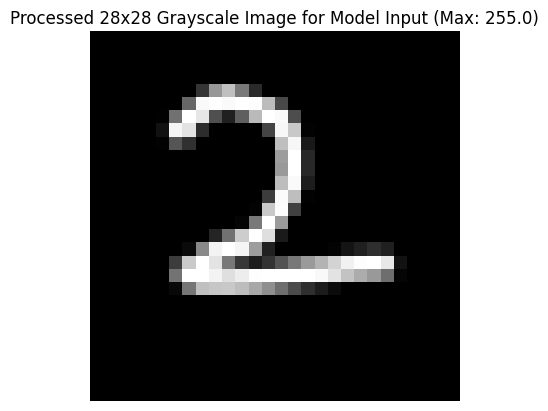

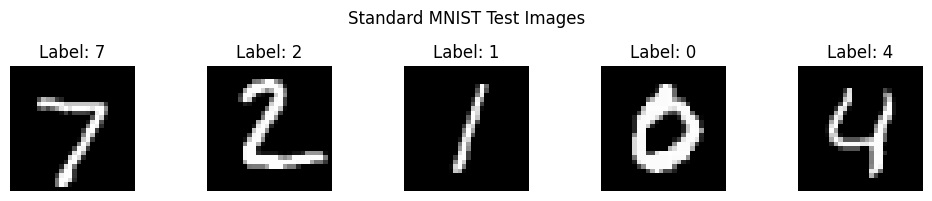

In [23]:
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Load the MNIST test dataset without normalization for visualization
mnist_display_transform = transforms.Compose([
    transforms.ToTensor()
])
raw_test_ds = datasets.MNIST("./data", train=False, download=True, transform=mnist_display_transform)

# Display a few example images
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
fig.suptitle("Standard MNIST Test Images", fontsize=12)

for i in range(5):
    image, label = raw_test_ds[i]
    axes[i].imshow(image.squeeze(), cmap='gray')
    axes[i].set_title(f"Label: {label}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

---
# Part 7 — Monitoring & data drift: models decay 📉

Deployment is the *beginning*, not the end. Real-world input data slowly stops matching training data — **data drift** — and accuracy silently rots. We simulate it: imagine users start photographing digits at an angle, or with noisy cameras.

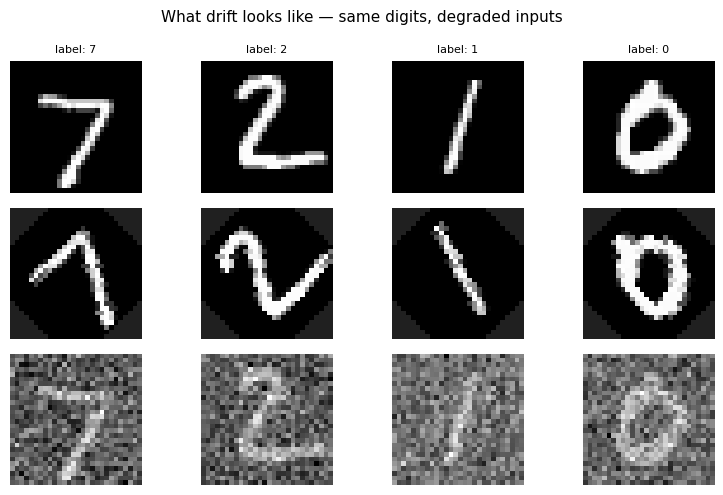

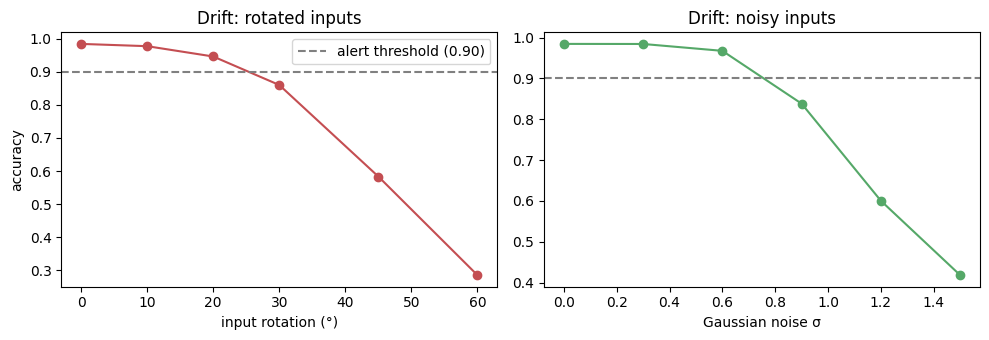

🚨 DRIFT ALERT: accuracy fell to 0.285 < 0.9 → trigger RETRAINING pipeline


In [12]:
import torchvision.transforms.functional as TF

# Evaluates model accuracy under simulated drift conditions:
# angle → rotates every image by that many degrees (simulates tilted camera)
# noise → adds random Gaussian noise to every pixel (simulates noisy camera)
@torch.no_grad()
def evaluate_under_drift(model, loader, angle=0.0, noise=0.0):
    model.eval()
    correct = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        if angle:
            x = TF.rotate(x, angle)           # rotate all images in the batch
        if noise:
            x = x + noise * torch.randn_like(x)  # add random pixel noise
        correct += (model(x).argmax(dim=1) == y).sum().item()
    return correct / len(loader.dataset)

# --- visualise what drifted inputs actually look like ---
# Pick 4 sample digits and show them original / rotated / noisy side by side
sample_imgs = torch.stack([test_ds[i][0] for i in range(4)])  # 4 clean images
sample_labels = [test_ds[i][1] for i in range(4)]

fig, axes = plt.subplots(3, 4, figsize=(8, 5))
fig.suptitle("What drift looks like — same digits, degraded inputs", fontsize=11)
for col in range(4):
    img = sample_imgs[col]
    # Row 0: original clean image
    axes[0, col].imshow(img.squeeze(), cmap="gray")
    axes[0, col].set_title(f"label: {sample_labels[col]}", fontsize=8)
    axes[0, col].axis("off")
    # Row 1: rotated 45 degrees
    rotated = TF.rotate(img.unsqueeze(0), angle=45).squeeze()
    axes[1, col].imshow(rotated, cmap="gray")
    axes[1, col].axis("off")
    # Row 2: heavy Gaussian noise (σ=1.2)
    noisy = (img + 1.2 * torch.randn_like(img)).squeeze()
    axes[2, col].imshow(noisy, cmap="gray")
    axes[2, col].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=8)
axes[1, 0].set_ylabel("Rotated 45°", fontsize=8)
axes[2, 0].set_ylabel("Noisy σ=1.2", fontsize=8)
plt.tight_layout()
plt.show()

# --- sweep across rotation angles and noise levels to measure accuracy drop ---
angles = [0, 10, 20, 30, 45, 60]
noises = [0.0, 0.3, 0.6, 0.9, 1.2, 1.5]
acc_rot   = [evaluate_under_drift(prod_model, test_loader, angle=a) for a in angles]
acc_noise = [evaluate_under_drift(prod_model, test_loader, noise=n) for n in noises]

# Log the monitoring results to MLflow — monitoring IS part of the lifecycle
with mlflow.start_run(run_name="production-monitoring"):
    for a, acc in zip(angles, acc_rot):
        mlflow.log_metric("accuracy_vs_rotation", acc, step=a)

# Plot accuracy vs. rotation and noise to see where the model breaks down
plt.figure(figsize=(10, 3.5))
plt.subplot(1, 2, 1)
plt.plot(angles, acc_rot, "o-", color="#C44E52")
plt.axhline(0.90, ls="--", color="gray", label="alert threshold (0.90)")
plt.xlabel("input rotation (°)"); plt.ylabel("accuracy"); plt.title("Drift: rotated inputs"); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(noises, acc_noise, "o-", color="#55A868")
plt.axhline(0.90, ls="--", color="gray")
plt.xlabel("Gaussian noise σ"); plt.title("Drift: noisy inputs")
plt.tight_layout(); plt.show()

# Trigger a retraining alert if any condition pushes accuracy below the threshold
ALERT = 0.90
worst = min(acc_rot + acc_noise)
if worst < ALERT:
    print(f"🚨 DRIFT ALERT: accuracy fell to {worst:.3f} < {ALERT} → trigger RETRAINING pipeline")
else:
    print("✅ Model healthy under tested conditions")

> 👩‍🏫 *For faculty:* in production, you usually **can't see true labels** in real time, so teams monitor *input distributions* (statistical tests on features) and *prediction confidence* as proxies. Open-source tool to demo next: **Evidently AI**. The standard fix for the drift above? Retrain with rotation/noise **augmentation** — and the loop begins again.

---
# Part 8 — The full MLOps lifecycle: what you just did 🔄

```
            ┌──────────────────────────────────────────────────────────┐
            │                                                          ▼
   DATA ──▶ TRAIN ──▶ TRACK ──▶ REGISTER ──▶ VALIDATE ──▶ DEPLOY ──▶ MONITOR
 (Part 2:   (Part 2:  (Part 3:   (Part 4:     (Part 5:     (Part 6:    (Part 7:
  versioned  seeds +   MLflow     MLflow       automated    Gradio /    drift
  datasets,  configs)  Tracking)  Registry)    gates)       FastAPI)    detection)
  DVC)                                                          │
            ▲                                                   │
            └────────────── drift alert → RETRAIN ◀─────────────┘
```

### Notebook tools → industry tools

| Concept | We used | Production-scale equivalents (all open-source friendly) |
|---|---|---|
| Config management | Python dict | Hydra, OmegaConf, YAML |
| Data versioning | (discussed) | DVC, LakeFS |
| Experiment tracking | MLflow (local) | MLflow server, W&B, Neptune |
| Model registry | MLflow Registry | MLflow, SageMaker, Vertex AI |
| Model distribution | **Hugging Face Hub** | HF Hub, S3/GCS artifact stores |
| Validation / CI | inline gate functions | pytest + GitHub Actions, Jenkins |
| Serving | Gradio | FastAPI + Docker + Kubernetes, TorchServe, BentoML |
| Monitoring | simulated drift | Evidently AI, Prometheus + Grafana, Arize |
| Orchestration | (not needed here) | Airflow, Prefect, Kubeflow Pipelines |

### 🧪 Take-home exercises (graded-assignment ready)
1. **Easy:** add `weight_decay` to `CONFIG`, sweep two values, find the winner in the MLflow leaderboard.
2. **Medium:** add a *fairness-style* gate — per-class accuracy must be ≥ 0.90 for **every** digit (hint: confusion matrix).
3. **Medium:** retrain with `transforms.RandomRotation(30)` augmentation, register it as **version 2**, and show the drift curve improving.
4. **Hard:** export the registry model with `torch.onnx.export` and serve it without PyTorch installed — discuss why deployment environments differ from training environments.

### 📚 Further reading
- *Hidden Technical Debt in Machine Learning Systems* (Sculley et al., NeurIPS 2015) — the paper that started it all
- MLflow docs: `mlflow.org` · DVC: `dvc.org` · Evidently: `evidentlyai.com`
- Google's *ML Test Score* rubric — a checklist your students can apply to any project

---
